# Atelier Préparation de Données Textuelles


In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

pd.set_option("display.max_colwidth", 60)
%matplotlib inline


[nltk_data] Downloading package punkt to /Users/owner/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/owner/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/owner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/owner/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 1) Charger les données CSV

In [8]:
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr


### 2) Combien d'avis contient le dataset ?

In [9]:
print(f"Nombre d'avis : {len(df)}")


Nombre d'avis : 1200


### 3) Combien de colonnes possède-t-il ?


In [10]:
print(f"Nombre de colonnes : {df.shape[1]}")
print(list(df.columns))

Nombre de colonnes : 8
['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### 4) Quel est le type de chaque colonne ?

In [11]:
print(df.dtypes)

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


### 5) Existe-t-il des valeurs manquantes ?


In [12]:
print(df.isna().sum())


id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


### 6) Identifier quelques types de texte


In [13]:

url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#\w+")
emoji_re = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]")
repeat_re = re.compile(r"(.)\1{2,}")

texte = df["texte"].fillna("")

exemples = {
    "texte normal": texte[(texte.str.len() > 10) & ~texte.str.contains(url_re) & ~texte.str.contains(mention_re)].iloc[0],
    "texte vide": df[df["texte"].isna() | (texte.str.strip() == "")].iloc[0]["texte"] if (df["texte"].isna().any() or (texte.str.strip()=="").any()) else "(aucun trouvé)",
    "texte avec URL": texte[texte.str.contains(url_re)].iloc[0],
    "texte avec mention": texte[texte.str.contains(mention_re)].iloc[0],
    "texte avec hashtag": texte[texte.str.contains(hashtag_re)].iloc[0],
    "texte avec emoji": texte[texte.str.contains(emoji_re)].iloc[0],
    "texte avec beaucoup de ponctuation": texte[texte.str.count(r"[!?.]{2,}") > 0].iloc[0],
    "texte en majuscules": texte[texte.str.isupper() & (texte.str.len() > 3)].iloc[0],
    "texte avec répétition de caractères": texte[texte.str.contains(repeat_re)].iloc[0],
}
for k, v in exemples.items():
    print(f"- {k} : {v!r}")


- texte normal : 'Très  bonne  expérience,  simple  et  efficace.'
- texte vide : nan
- texte avec URL : 'Produit parfait, rien à signaler. https://example.com/commande/17'
- texte avec mention : '@client Livraison rapide et produit conforme à mes attentes.'
- texte avec hashtag : 'Très satisfait de mon achat 👍 #avis'
- texte avec emoji : 'Très satisfait de mon achat 👍 #avis'
- texte avec beaucoup de ponctuation : 'Produit excellent, je suis très satisfait. !!!'
- texte en majuscules : "LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."
- texte avec répétition de caractères : 'Produit excellent, je suis très satisfait. !!!'


/var/folders/0h/_d5jczk96_v7v7jl988tw0xm0000gn/T/ipykernel_15692/4254936145.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "texte avec répétition de caractères": texte[texte.str.contains(repeat_re)].iloc[0],


### 7) Longueur des textes

In [14]:

df["longueur"] = df["texte"].fillna("").str.len()
stats = df["longueur"].describe(percentiles=[0.25, 0.5, 0.75])
print(f"Longueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne  : {df['longueur'].mean():.2f}")
print(f"Médiane           : {df['longueur'].median():.2f}")
print(f"Q1 (25%)          : {df['longueur'].quantile(0.25):.2f}")
print(f"Q3 (75%)          : {df['longueur'].quantile(0.75):.2f}")


Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 48.96
Médiane           : 48.00
Q1 (25%)          : 37.00
Q3 (75%)          : 56.00


### 8) Visualiser la distribution de la longueur des avis


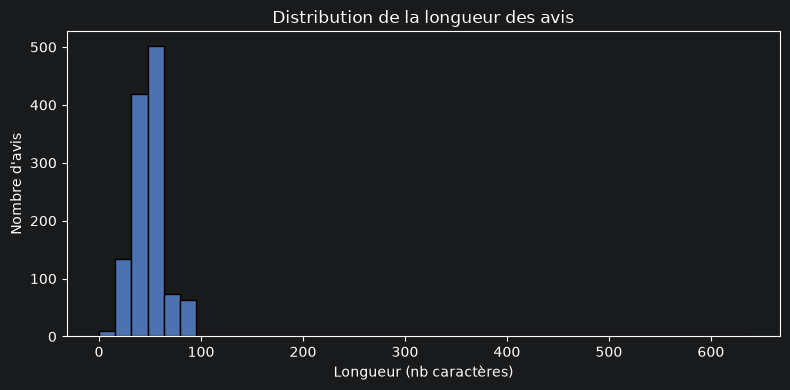

In [15]:
plt.figure(figsize=(8,4))
plt.hist(df["longueur"], bins=40, color="#4C72B0", edgecolor="black")
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (nb caractères)")
plt.ylabel("Nombre d'avis")
plt.tight_layout()
plt.savefig("_tmp.png")

**a) Existe-t-il des textes anormalement longs ?**
Oui : 11 avis dépassent le 99e centile de longueur (87 caractères), ce qui constitue une petite queue de distribution à surveiller (potentiels avis composites ou concaténations).


**b) Existe-t-il beaucoup de textes très courts ?**
Oui, 9 avis ont moins de 15 caractères — probablement peu informatifs pour la classification de sentiment (ex. « bien. », « nul »).

### 9) Détecter les textes vides

In [16]:

vides = df[df["texte"].isna() | (df["texte"].fillna("").str.strip() == "")]
print(f"Nombre de textes vides : {len(vides)}")
print(vides[["id_avis","source","texte"]].head())


Nombre de textes vides : 6
    id_avis           source texte
46   AV0047  réseaux_sociaux   NaN
108  AV0109            email   NaN
310  AV0311  réseaux_sociaux   NaN
640  AV0641  réseaux_sociaux   NaN
781  AV0782            email   NaN


### 10) Détecter les doublons sur le texte

In [17]:

doublons = df[df["texte"].duplicated(keep=False) & df["texte"].notna()]
print(f"Nombre de lignes impliquées dans un doublon de texte : {len(doublons)}")
print(f"Nombre de textes uniques dupliqués : {df['texte'].dropna().duplicated().sum()}")


Nombre de lignes impliquées dans un doublon de texte : 1031
Nombre de textes uniques dupliqués : 877


### 11) Les classes sont-elles équilibrées ?


In [18]:

counts = df["sentiment"].value_counts()
pct = df["sentiment"].value_counts(normalize=True) * 100
print(counts)
print()
print(pct.round(2))
print()
print(f"Classe majoritaire : {counts.idxmax()} ({counts.max()} avis, {pct.max():.1f}%)")


sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64

Classe majoritaire : positif (776 avis, 64.7%)


/ 12) Quelle est la classe majoritaire ?

Les classes ne sont pas parfaitement équilibrées : l'écart entre la classe majoritaire et la classe minoritaire est visible ci-dessus. Ce déséquilibre, sans être extrême, doit être pris en compte pour le choix des métriques et, potentiellement, pour une stratégie de rééquilibrage (class_weight, sur/sous-échantillonnage).